In [1]:
import astropy
import astroquery.simbad
import numpy as np
from astropy.table import Table
from astropy.io import ascii
import astropy.units as u
from astropy.coordinates import SkyCoord
import pyarrow
import pyvo
from astroquery.simbad import Simbad
from astroquery.ipac.nexsci.nasa_exoplanet_archive import NasaExoplanetArchive
from collections import Counter
import timeit
import matplotlib.pyplot as plt
import pandas
import os

In [2]:
%load_ext autoreload
%autoreload 1
%aimport crossmatching
from crossmatching import Crossmatcher


In [3]:
cm = Crossmatcher()
cm.load_catalog(from_file="pscomppars.txt")
input = ascii.read("./input/HPIC_LC4_combined_d50.txt")
name_list = input["star_name"]
_ = cm.load_alternate_ids(name_list, from_file="alternate_ids.txt")

In [4]:
set(cm.coordinate_crossmatch(input)[0].keys()) - set(cm.coordinate_crossmatch(input)[1].keys())
# yay 

{'3d_sep'}

In [5]:
set(cm.coordinate_crossmatch(input)[0].keys()) - set(cm.id_crossmatch(input).keys())

{'3d_sep'}

In [6]:
set(cm.id_crossmatch(input).keys()) - set(cm.coordinate_crossmatch(input)[0].keys())

{'id', 'input_ids'}

In [7]:
cm.combined_crossmatch(input)

star_name,sy_dist_input,st_spectype_input,st_rad_input,st_teff_input,st_mass_input,st_age_input,ra_input,dec_input,sy_vmag_input,sy_jmag_input,sy_hmag_input,sy_kmag_input,known_binary_fl,gaia_binary_fl,WDSsep,wds_deltamag,objectid,pl_name,pl_letter,hostid,hostname,hd_name,hip_name,tic_id,disc_pubdate,disc_year,disc_method,discoverymethod,disc_locale,disc_facility,disc_instrument,disc_telescope,disc_refname,ra_cat,raerr1,raerr2,rasymerr,rastr,ra_solnid,ra_reflink,dec_cat,decerr1,decerr2,decsymerr,decstr,dec_solnid,dec_reflink,glon,glonerr1,glonerr2,glonsymerr,glonstr,glon_solnid,glon_reflink,glat,glaterr1,glaterr2,glatsymerr,glatstr,glat_solnid,glat_reflink,elon,elonerr1,elonerr2,elonsymerr,elonstr,elon_solnid,elon_reflink,elat,elaterr1,elaterr2,elatsymerr,elat_solnid,elat_reflink,elatstr,pl_orbper,pl_orbpererr1,pl_orbpererr2,pl_orbpersymerr,pl_orbperlim,pl_orbperstr,pl_orbperformat,pl_orbper_solnid,pl_orbper_reflink,pl_orblpererr1,pl_orblper,pl_orblpererr2,pl_orblpersymerr,pl_orblperlim,pl_orblperstr,pl_orblperformat,pl_orblper_solnid,pl_orblper_reflink,pl_orbsmax,pl_orbsmaxerr1,pl_orbsmaxerr2,pl_orbsmaxsymerr,pl_orbsmaxlim,pl_orbsmaxstr,pl_orbsmaxformat,pl_orbsmax_solnid,pl_orbsmax_reflink,pl_orbincl,pl_orbinclerr1,pl_orbinclerr2,pl_orbinclsymerr,pl_orbincllim,pl_orbinclstr,pl_orbinclformat,pl_orbincl_solnid,pl_orbincl_reflink,pl_orbtper,pl_orbtpererr1,pl_orbtpererr2,pl_orbtpersymerr,pl_orbtperlim,pl_orbtperstr,pl_orbtperformat,pl_orbtper_solnid,pl_orbtper_reflink,pl_orbeccen,pl_orbeccenerr1,pl_orbeccenerr2,pl_orbeccensymerr,pl_orbeccenlim,pl_orbeccenstr,pl_orbeccenformat,pl_orbeccen_solnid,pl_orbeccen_reflink,pl_eqt,pl_eqterr1,pl_eqterr2,pl_eqtsymerr,pl_eqtlim,pl_eqtstr,pl_eqtformat,pl_eqt_solnid,pl_eqt_reflink,pl_occdep,pl_occdeperr1,pl_occdeperr2,pl_occdepsymerr,pl_occdeplim,pl_occdepstr,pl_occdepformat,pl_occdep_solnid,pl_occdep_reflink,pl_insol,pl_insolerr1,pl_insolerr2,pl_insolsymerr,pl_insollim,pl_insolstr,pl_insolformat,pl_insol_solnid,pl_insol_reflink,pl_dens,pl_denserr1,sy_umagerr1,sy_umagerr2,sy_umaglim,sy_umagsymerr,sy_umagstr,sy_umagformat,sy_umag_solnid,sy_umag_reflink,sy_rmag,sy_rmagerr1,sy_rmagerr2,sy_rmaglim,sy_rmagsymerr,sy_rmagstr,sy_rmagformat,sy_rmag_solnid,sy_rmag_reflink,sy_imag,sy_imagerr1,sy_imagerr2,sy_imaglim,sy_imagsymerr,sy_imagstr,sy_imagformat,sy_imag_solnid,sy_imag_reflink,sy_zmag,sy_zmagerr1,sy_zmagerr2,sy_zmaglim,sy_zmagsymerr,sy_zmagstr,sy_zmagformat,sy_zmag_solnid,sy_zmag_reflink,sy_w1mag,sy_w1magerr1,sy_w1magerr2,sy_w1maglim,sy_w1magsymerr,sy_w1magstr,sy_w1magformat,sy_w1mag_solnid,sy_w1mag_reflink,sy_w2mag,sy_w2magerr1,sy_w2magerr2,sy_w2maglim,sy_w2magsymerr,sy_w2magstr,sy_w2magformat,sy_w2mag_solnid,sy_w2mag_reflink,sy_w3mag,sy_w3magerr1,sy_w3magerr2,sy_w3maglim,sy_w3magsymerr,sy_w3magstr,sy_w3magformat,sy_w3mag_solnid,sy_w3mag_reflink,sy_w4mag,sy_w4magerr1,sy_w4magerr2,sy_w4maglim,sy_w4magsymerr,sy_w4magstr,sy_w4magformat,sy_w4mag_solnid,sy_w4mag_reflink,sy_gmag,sy_gmagerr1,sy_gmagerr2,sy_gmaglim,sy_gmagsymerr,sy_gmagstr,sy_gmagformat,sy_gmag_solnid,sy_gmag_reflink,sy_gaiamag,sy_gaiamagerr1,sy_gaiamagerr2,sy_gaiamaglim,sy_gaiamagsymerr,sy_gaiamagstr,sy_gaiamagformat,sy_gaiamag_solnid,sy_gaiamag_reflink,sy_tmag,sy_tmagerr1,sy_tmagerr2,sy_tmaglim,sy_tmagsymerr,sy_tmagstr,sy_tmagformat,sy_tmag_solnid,sy_tmag_reflink,sy_name,pl_controv_flag,pl_orbtper_systemref,pl_tranmid_systemref,st_metratio,st_spectype_cat,st_spectype_solnid,st_spectype_reflink,sy_plxlim,sy_kepmag,sy_kepmagerr1,sy_kepmagerr2,sy_kepmaglim,sy_kepmagsymerr,sy_kepmagstr,sy_kepformat,sy_kepmag_solnid,sy_kepmag_reflink,st_rotp,st_rotperr1,st_rotperr2,st_rotpsymerr,st_rotplim,st_rotpstr,st_rotpformat,st_rotp_solnid,st_rotp_reflink,pl_projobliq,pl_projobliqerr1,pl_projobliqerr2,pl_projobliqsymerr,pl_projobliqlim,pl_projobliqstr,pl_projobliqformat,pl_denserr2,pl_denssymerr,pl_denslim,pl_densstr,pl_densformat,pl_dens_solnid,pl_dens_reflink,pl_trandep,pl_trandeperr1,pl_trandeperr2,pl_trandepsymerr,pl_trandeplim,pl_trandepstr,pl_tra

In [8]:
print(len(set(cm.id_matched["pl_name"])), len(cm.id_matched))
# good this means that every planet is unique
print(len(set(cm.id_matched["star_name"])))  
print(len(set(cm.id_matched["hostname"])))
print(len(input), len(set(input["star_name"])))
# alright input contains a duplicate
# so in short, we expect a lot of systmes to be matched with multiple planets

473 477
302
301
14571 14570


In [9]:
print(len(set(cm.id_matched["pl_name"])), len(cm.id_matched))
print(len(input), len(set(input["star_name"])))
# planets 

473 477
14571 14570


In [10]:
len(cm.matched)

827

In [11]:
Counter(cm.matched["match_type"])

Counter({np.str_('id'): 477, np.str_('2d'): 296, np.str_('3d'): 54})

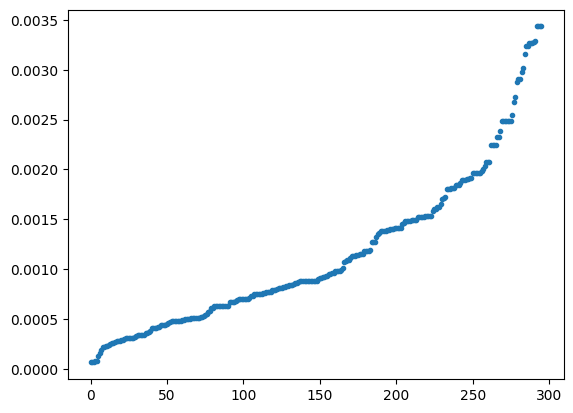

In [12]:
plt.plot(np.sort(cm.matched["2d_sep"]), '.')

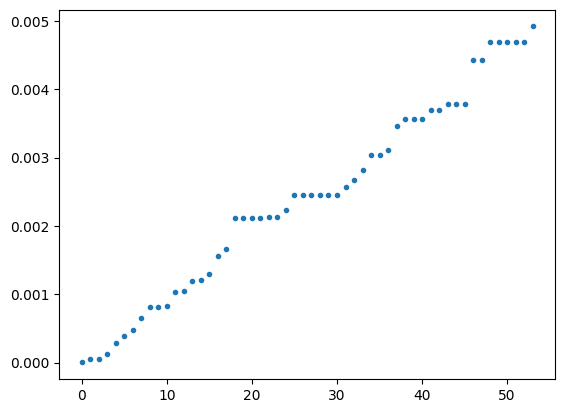

In [13]:
plt.plot(np.sort(cm.matched["3d_sep"]), '.')

In [14]:
Counter(cm.catalogue["pl_name"])

Counter({np.str_('Kepler-1167 b'): 1,
         np.str_('Kepler-1740 b'): 1,
         np.str_('Kepler-1581 b'): 1,
         np.str_('Kepler-644 b'): 1,
         np.str_('Kepler-1752 b'): 1,
         np.str_('Kepler-280 c'): 1,
         np.str_('Kepler-1208 b'): 1,
         np.str_('Kepler-263 c'): 1,
         np.str_('Kepler-1101 b'): 1,
         np.str_('HD 168746 b'): 1,
         np.str_('K2-19 b'): 1,
         np.str_('Kepler-560 b'): 1,
         np.str_('Kepler-150 d'): 1,
         np.str_('Kepler-498 b'): 1,
         np.str_('Kepler-817 b'): 1,
         np.str_('Kepler-937 b'): 1,
         np.str_('K2-10 b'): 1,
         np.str_('Kepler-571 b'): 1,
         np.str_('Kepler-1458 b'): 1,
         np.str_('K2-335 b'): 1,
         np.str_('Kepler-1600 c'): 1,
         np.str_('Kepler-221 d'): 1,
         np.str_('Kepler-626 b'): 1,
         np.str_('Kepler-1549 b'): 1,
         np.str_('K2-62 c'): 1,
         np.str_('Kepler-1149 b'): 1,
         np.str_('Kepler-1288 b'): 1,
         n

In [15]:
final = cm.combined_crossmatch(input)
print(len(cm.id_matched))
print(len(cm.coords3d_matched))
print(len(cm.coords2d_matched))
print(Counter(final["match_type"]))
print(len(final), len(set(final["pl_name"]))) # this shouldn't happen
# final["pl_name", "match_type"]].to_pandas().sort_values("pl_name").to_csv("final_crossmatch.csv", index=False)
# final["pl_name", "match_type"].to_pandas().groupby("pl_name").count().sort_values("match_type", ascending=False)
final["pl_name", "star_name", "hostname", "id", "match_type"][np.isin(final["pl_name"], ["HD 46375 b", "DS Tuc A b",  "GJ 887 b", "GJ 887 c", "GJ 887 d"])]
# we conclude that the combination might work, but both methods can produce duplicates, need to further investigate why

477
152
727
Counter({np.str_('id'): 477, np.str_('2d'): 296, np.str_('3d'): 54})
827 823


pl_name,star_name,hostname,id,match_type
str29,str29,str27,str23,str2
GJ 887 b,TIC 471015557,GJ 887,GJ 887,id
GJ 887 b,TIC 155315739,GJ 887,GJ 887,id
GJ 887 c,TIC 471015557,GJ 887,GJ 887,id
GJ 887 c,TIC 155315739,GJ 887,GJ 887,id
GJ 887 d,TIC 471015557,GJ 887,GJ 887,id
GJ 887 d,TIC 155315739,GJ 887,GJ 887,id
HD 46375 b,TIC 234928947,HD 46375,--,2d
DS Tuc A b,TIC 410214986,DS Tuc A,--,2d
